# Zenodo CyberLab Dataset - Honeyynet Behvaioral Clustering 

This notebook analyzes session level honeypot data to model attacker behavior pattern through clustering. 
- Parse real honepot logs
- Extract session behavior features
- Compute password entropy using Shannon entropy
- Cluster attacker behavior 

Zenodo CyberLab Dataset:
This dataset contains real attacker interaction logs (connect, auth attempts, commands, etc.) with timestamps and session_id and will be used to train and validate feature extraction on realistic attacker sessions. Used for attacker behvaior modeling. 

Information to download the dataset are in `machine-learning/data/READ.me`



In [1]:
#uncomment to check which python version/enviornment is running script 
#import sys
#print(sys.executable)

#imports
import os
import json
import gzip
import math
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA


### Shannon Entropy 
Shannon entropy measures password strength in bits, representing min number of guesses needed to guess it.

The Shannon entropy is defined as:
$$
H = -\sum_{i=1}^{n} p(x_i)\log_2 p(x_i)
$$

where:
- $p(x_i)$ is the probability of character $x_i$ in the password  
- $n$ is the number of unique characters  

This helps us measure how unpredictable a password string is.

- Higher entropy → more randomness → more human-like
- Medium entropy → common human style passwords
- Lower entropy → repetitive/simple → more bot-like

<u> Character distribution entropy:</u> Instead of estimating entropy from the allowed character pool, we compute it from the actual characters used. This better captures repetition patterns, structured guesses, and dictionary based attacks.

In our pipeline, entropy is computed per password attempt and can be aggregated per session (mean entropy or maximum entropy) to characterize attacker behavior.


In [2]:
def shannon_entropy(s:str) ->float:
    #handles missing values or nons trings
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return 0.0
    
    s=str(s)
    if len(s) == 0:
        return 0.0
        
    #counts how many times each character appears
    #stored in dict - ex: "aab1"-> {'a':2, 'b':1, '1':1}
    counts= {}
    for ch in s:
        counts[ch]= counts.get(ch, 0)+1
    
    #compute probability by dividing count by total length of string
    #ex: [2,1,1]/4 -> [0.5, 0.25, 0.25]
    probs= np.array(list(counts.values()), dtype=float)/ len(s)
    #apply shannon entropy formula 
    #measures how unpredictable the character distribution is
    entropy= -(probs*np.log2(probs)).sum()

    #low values -> low entropy 
    #high values -> high entropy 
    return float(entropy)

### Zenodo CyberLab Honeynet Dataset
Contains session level logs including:
- Timestamps
- Event IDs
- Commands
- Password attempts
- Session identifiers 

`['session_id', 'dst_host_identifier', 'eventid', 'timestamp', 'src_ip_identifier', 'dst_ip_identifier', 'message', 'protocol', 'src_port', 'sensor', 'geolocation_data', 'arch', 'duration', 'ssh_client_version', 'username', 'password', 'hasshAlgorithms', 'macCS', 'langCS', 'compCS', 'encCS', 'hassh', 'kexAlgs', 'keyAlgs', 'fingerprint', 'key', 'type', 'outfile', 'destfile', 'duplicate', 'shasum', 'url', 'ttylog', 'size', 'filename', 'data']`

### Preprocessing


In [3]:
ZENODO_DIR= Path("../data/Zenodo Honeypot Data")  
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
def zenod_events(path:Path) ->Iterable[Dict[str,Any]]:
    with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)

            if isinstance(obj, list):
                for item in obj:
                    if isinstance(item, dict):
                        for _, events in item.items():
                            if isinstance(events, list):
                                for ev in events:
                                    if isinstance(ev, dict):
                                        yield ev
            elif isinstance(obj,dict):
                for _,events in obj.items():
                    if isinstance(events,list):
                        for ev in events:
                            if isinstance(ev,dict):
                                yield ev

def load_zenodo(max_events: int|None=None)-> pd.DataFrame:
    rows=[]
    seen=0

    for fpath in sorted(ZENODO_DIR.glob("*.json")):
        print("File:", fpath.name)
        for ev in zenod_events(fpath):
            rows.append(ev)
            seen+=1

            if max_events is not None and seen >= max_events:
                break
        if max_events is not None and seen >= max_events:
                break

    return pd.DataFrame(rows) 

zen_df= load_zenodo()
print("Columns:", zen_df.columns.tolist())
print("Total columns:", len(zen_df.columns))

print("Zendo Events:", zen_df.shape)
zen_df.head()


File: cowrie_2019-05-13.json
File: cowrie_2019-05-14.json
File: cowrie_2019-05-15.json
File: cowrie_2019-05-16.json
File: cowrie_2019-05-17.json
Columns: ['session_id', 'dst_host_identifier', 'eventid', 'timestamp', 'src_ip_identifier', 'dst_ip_identifier', 'message', 'protocol', 'src_port', 'sensor', 'geolocation_data', 'arch', 'duration', 'ssh_client_version', 'username', 'password', 'hasshAlgorithms', 'macCS', 'langCS', 'compCS', 'encCS', 'hassh', 'kexAlgs', 'keyAlgs', 'fingerprint', 'key', 'type', 'outfile', 'destfile', 'duplicate', 'shasum', 'url', 'ttylog', 'size', 'filename', 'data']
Total columns: 36
Zendo Events: (190670, 36)


,session_id,dst_host_identifier,eventid,timestamp,src_ip_identifier,dst_ip_identifier,message,protocol,src_port,sensor,geolocation_data,arch,duration,ssh_client_version,username,password,hasshAlgorithms,macCS,langCS,compCS,encCS,hassh,kexAlgs,keyAlgs,fingerprint,key,type,outfile,destfile,duplicate,shasum,url,ttylog,size,filename,data
0,0b74e20e,0b6413ddbb3aebd1e5b4f226a60016af8c6138386a8195d453c7dbda2cbbef38,cowrie.session.connect,2019-05-13T00:01:29.572648Z,2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e,None,New connection: 2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e:48988 (172.22.0.2:2222) [session: 0b74e20e],None,48988.0,2ff702a541a4,"{'country_name': 'Ireland', 'continent_code': 'EU', 'timezone': 'Europe/Dublin', 'region_code': 'CO', 'country_code2': 'IE', 'location': {'lon': -8.95, 'lat': 51.9}, 'region_name': 'County Cork', 'latitude': 51.9, 'country_code3': 'IE', 'ip': '2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e', 'longitude': -8.95, 'city_name': 'Macroom'}",None,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,NaN,None,None,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN
1,0b74e20e,0b6413ddbb3aebd1e5b4f226a60016af8c6138386a8195d453c7dbda2cbbef38,cowrie.session.closed,2019-05-13T00:01:29.711210Z,2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e,None,Connection lost after 0 seconds,None,NaN,2ff702a541a4,"{'country_name': 'Ireland', 'continent_code': 'EU', 'timezone': 'Europe/Dublin', 'region_code': 'CO', 'country_code2': 'IE', 'location': {'lon': -8.95, 'lat': 51.9}, 'region_name': 'County Cork', 'latitude': 51.9, 'country_code3': 'IE', 'ip': '2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e', 'longitude': -8.95, 'city_name': 'Macroom'}",None,0.137386,NaN,NaN,NaN,None,None,None,None,None,None,None,None,NaN,None,None,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN
2,d54146f3,0b6413ddbb3aebd1e5b4f226a60016af8c6138386a8195d453c7dbda2cbbef38,cowrie.session.connect,2019-05-13T00:01:29.626202Z,276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9,None,New connection: 276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9:39175 (172.22.0.2:2222) [session: d54146f3],None,39175.0,2ff702a541a4,"{'country_name': 'Ireland', 'continent_code': 'EU', 'timezone': 'Europe/Dublin', 'region_code': 'CO', 'country_code2': 'IE', 'location': {'lon': -8.95, 'lat': 51.9}, 'region_name': 'County Cork', 'latitude': 51.9, 'country_code3': 'IE', 'ip': '276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9', 'longitude': -8.95, 'city_name': 'Macroom'}",None,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,NaN,None,None,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN
3,d54146f3,0b6413ddbb3aebd1e5b4f226a60016af8c6138386a8195d453c7dbda2cbbef38,cowrie.client.version,2019-05-13T00:01:30.104744Z,276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9,None,Remote SSH version: SSH-2.0-Go,None,NaN,2ff702a541a4,"{'country_name': 'Ireland', 'continent_code': 'EU', 'timezone': 'Europe/Dublin', 'region_code': 'CO', 'country_code2': 'IE', 'location': {'lon': -8.95, 'lat': 51.9}, 'region_name': 'County Cork', 'latitude': 51.9, 'country_code3': 'IE', 'ip': '276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9', 'longitude': -8.95, 'city_name': 'Macroom'}",None,NaN,SSH-2.0-Go,NaN,NaN,None,"[hmac-sha2-256-etm@openssh.com, hmac-sha2-256, hmac-sha1, hmac-sha1-96]",None,[none],"[aes128-ctr, aes192-ctr, aes256-ctr, aes128-gcm@openssh.com, arcfour256, arcfour128, aes128-cbc, arcfour, 3des-cbc]",None,"[curve25519-sha256@libssh.org, ecdh-sha2-nistp256, ecdh-sha2-nistp384, ecdh-sha2-nistp521, diffie-hellman-group14-sha1, diffie-hellman-group1-sha1]","[ssh-rsa-cert-v01@openssh.com, ssh-dss-cert-v01@openssh.com, ecdsa-sha2-nistp256-cert-v01@openssh.com, ecdsa-sha2-nistp384-cert-v01@openssh.com, ecdsa-sha2-nistp521-cert-v01@openssh.com, ssh-ed25519-cert-v01@openssh.com, ecdsa-sha2-nistp256, ecdsa-sha2-nistp384, ecdsa-sha2-nistp521, ssh-rsa, ssh-dss,

### Feature extraction from session elements
Compute core behavioral features:
- session_duration_s: last timestamp - first timestamp
- command_count: number of "command-like" events (based on eventid)
- commands_per_min: command_count / duration
- avg_password_entropy: mean entropy across attempted passwords within a session

In [4]:
#parse time and event type

zen_df["timestamp"]= pd.to_datetime(zen_df["timestamp"],errors="coerce", utc=True)
print("Null timestamps:", int(zen_df["timestamp"].isna().sum()))

zen_df["eventid"].value_counts().head(15)

#session feature extraction


Null timestamps: 0


eventid
cowrie.session.connect          40879
cowrie.session.closed           40879
cowrie.direct-tcpip.request     32851
cowrie.client.version           27975
cowrie.login.success            26398
cowrie.login.failed              9030
cowrie.direct-tcpip.data         8683
cowrie.command.success           2853
cowrie.log.open                   504
cowrie.session.file_download      260
cowrie.log.closed                 239
cowrie.client.fingerprint          70
cowrie.client.size                 39
cowrie.command.failed              10
Name: count, dtype: int64

In [5]:
df= zen_df.copy()

for col in ["session_id", "timestamp", "eventid", "password"]:
    if col not in df.columns:
        df[col]= None

df= df.dropna(subset=["timestamp"])
feats=[]

for session_id, g in df.groupby("session_id"):
    start= g["timestamp"].min()
    end=g["timestamp"].max()
    duration_s=(end-start).total_seconds()

    # command count (based on event type)
    cmd_count = int(np.sum(
        g["eventid"].apply(
            lambda x: isinstance(x, str) and ("cowrie.command" in x)
        )
    ))

    pw_series= g["password"].dropna()
    entropies= [shannon_entropy(pw) for pw in pw_series.tolist()]
    avg_entropy= float(np.mean(entropies)) if len(entropies) else 0.0 

    #avoid dividing by 0
    MIN_DUR_S= 0.5
    if duration_s <MIN_DUR_S:
        if duration_s==0:
            cmds_per_min= 0.0
        else:
            cmds_per_min= cmd_count/(MIN_DUR_S/60.0)
    else:
        cmds_per_min=cmd_count/(duration_s/60.0)
    
    feats.append({
        "session_id": session_id,
        "start_time": start,
        "end_time": end,
        "session_duration_s": duration_s,
        "command_count": cmd_count,
        "commands_per_min": cmds_per_min,
        "avg_password_entropy": avg_entropy,
    })

zen_sessions= pd.DataFrame(feats)
zen_sessions.replace([np.inf, -np.inf], np.nan, inplace=True)
zen_sessions.fillna(0.0, inplace=True)
print("Zenodo session features shape:", zen_sessions.shape)
zen_sessions.head()
    

Zenodo session features shape: (40874, 7)


,session_id,start_time,end_time,session_duration_s,command_count,commands_per_min,avg_password_entropy
0,00002bde,2019-05-14 22:50:11.791287+00:00,2019-05-15 01:04:44.980779+00:00,8073.189492,0,0.0,2.321928
1,00019043,2019-05-15 20:56:56.041824+00:00,2019-05-15 20:56:57.117749+00:00,1.075925,0,0.0,2.321928
2,00026a37,2019-05-16 14:30:02.466333+00:00,2019-05-16 14:30:03.394699+00:00,0.928366,0,0.0,2.321928
3,0002ff7b,2019-05-14 19:27:02.225593+00:00,2019-05-14 19:27:03.609317+00:00,1.383724,0,0.0,2.321928
4,00035ea9,2019-05-13 00:43:41.449767+00:00,2019-05-13 00:43:42.383863+00:00,0.934096,0,0.0,2.321928


### Plot distributions

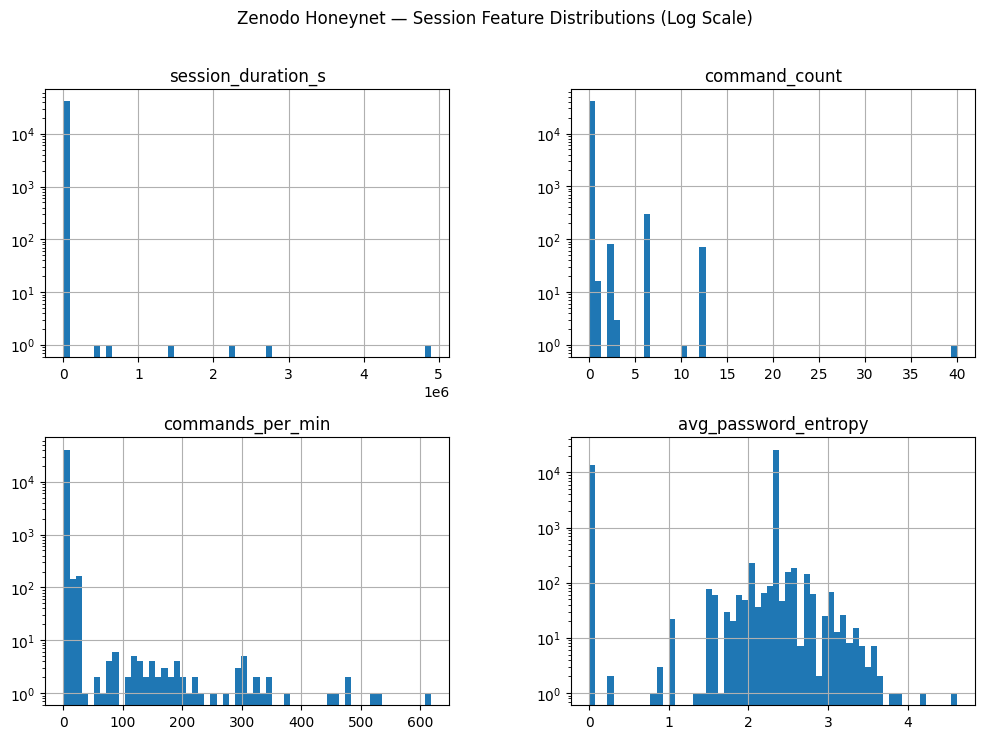

In [6]:
zen_cols = ["session_duration_s", "command_count", "commands_per_min", "avg_password_entropy"]
zen_sessions[zen_cols].hist(bins=60, figsize=(12,8), log=True)
plt.suptitle("Zenodo Honeynet — Session Feature Distributions (Log Scale)")
plt.show()

### Attacker Behavior Model
We cluster session behaviors to discover latent attacker profiles
Steps:
1. Log transform features
2. Standardize
3. Compute silhouette scores for optimal K
4. Fit KMeans
5. Interpret cluster centers

This helps differentiate:
- Scanners
- Brute-force attackers
- High automation bots
- Manual interactive sessions


In [7]:
zen_cols=[
    "session_duration_s",
    "command_count",
    "commands_per_min",
    "avg_password_entropy"
]
X_attack= zen_sessions[zen_cols].copy()
X_attack.replace([np.inf, -np.inf], np.nan, inplace=True)
X_attack.fillna(0.0, inplace=True)

X_attack.describe()

,session_duration_s,command_count,commands_per_min,avg_password_entropy
count,4.087400e+04,40874.000000,40874.000000,40874.000000
mean,3.851772e+02,0.070045,0.551318,1.558080
std,3.108416e+04,0.747114,10.639579,1.095698
min,3.106000e-03,0.000000,0.000000,0.000000
25%,2.289495e-01,0.000000,0.000000,0.000000
50%,1.046549e+00,0.000000,0.000000,2.321928
75%,2.424398e+00,0.000000,0.000000,2.321928
max,4.900003e+06,40.000000,618.220504,4.612649


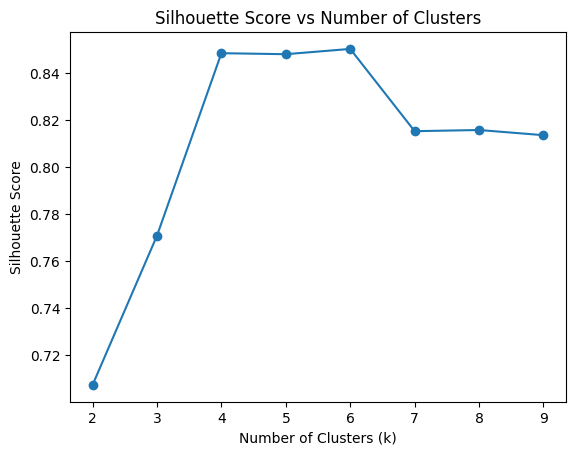

Best k: 6


In [8]:
for col in zen_cols:
    X_attack[col]= np.log1p(X_attack[col])

scaler_attack= StandardScaler()
X_attack_scaled= scaler_attack.fit_transform(X_attack)

sil_scores=[]
k_range= range(2,10)

for k in k_range:
    km=KMeans(n_clusters =k, random_state=42)
    labels= km.fit_predict(X_attack_scaled)
    score= silhouette_score(X_attack_scaled, labels)
    sil_scores.append(score)

plt.plot(k_range,sil_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

print("Best k:", k_range[np.argmax(sil_scores)])


In [9]:
k_opt= k_range[np.argmax(sil_scores)]

kmeans_attack= KMeans(n_clusters=k_opt, random_state=42)
zen_sessions["attack_cluster"]= kmeans_attack.fit_predict(X_attack_scaled)

print("Cluster counts:")
print(zen_sessions["attack_cluster"].value_counts().sort_index())
cluster_summary = zen_sessions.groupby("attack_cluster")[zen_cols].agg(["count", "mean", "median"])
cluster_summary

Cluster counts:
attack_cluster
0    13268
1    24771
2       71
3      486
4      373
5     1905
Name: count, dtype: int64


session_duration_s                            command_count  \
                            count          mean       median         count   
attack_cluster                                                               
0                           13268      0.245326     0.157400         13268   
1                           24771      2.348433     1.215439         24771   
2                              71      4.679223     4.000330            71   
3                             486  31718.265958  7104.911532           486   
4                             373     26.279021    15.210344           373   
5                            1905    134.956923   170.637565          1905   

                                 commands_per_min                            \
                     mean median            count          mean      median   
attack_cluster                                                                
0                0.000000    0.0            13268  0.000000e+00    0.000000   
1                0.000000    0.0            24771  0.000000e+00    0.000000   
2               12.000000   12.0               71  2.156388e+02  179.985151   
3                0.012346    0.0              486  2.680679e-07    0.000000   
4                5.297587    6.0              373  1.934264e+01   19.318430   
5                0.015223    0.0             1905  4.930496e-03    0.000000   

               avg_password_entropy                      
                              count      mean    median  
attack_cluster                                           
0                             13268  0.000022  0.000000  
1                             24771  2.322952  2.321928  
2                                71  2.689574  2.750000  
3                               486  2.322136  2.321928  
4                               373  2.040333  2.521641  
5                              1905  2.132422  2.321928

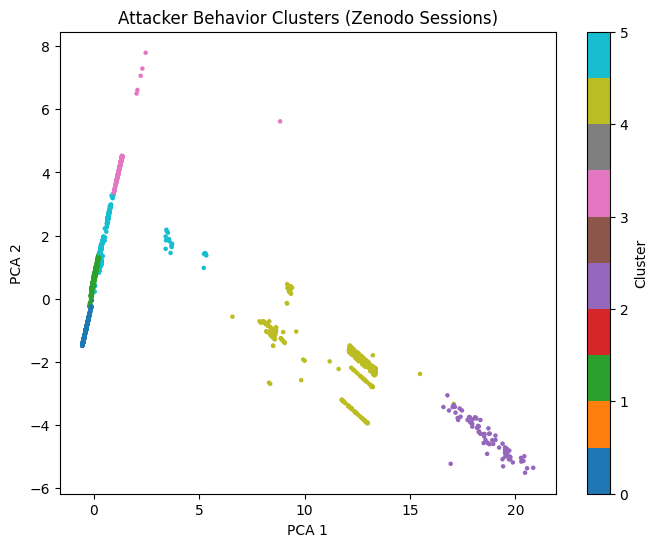

In [10]:
def label_cluster(row):
    if row["command_count"]<2:
        return "Scanner / Probe"
    elif row["avg_password_entropy"]>3:
        return "Brute Force / Credential Stuffing"
    elif row["commands_per_min"]>10:
        return "High Automation Bot"
    else:
        return "Interactive / Manual"

cluster_labels= {}

for cid in zen_sessions["attack_cluster"].unique():
    subset = zen_sessions[zen_sessions["attack_cluster"] == cid]
    avg = subset[zen_cols].mean()
    cluster_labels[cid]= label_cluster(avg)

zen_sessions["attack_type"]= zen_sessions["attack_cluster"].map(cluster_labels)

zen_sessions[["attack_cluster", "attack_type"]].drop_duplicates().sort_values("attack_cluster")

pca= PCA(n_components=2)
X_pca= pca.fit_transform(X_attack_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=zen_sessions["attack_cluster"], cmap="tab10", s=5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Attacker Behavior Clusters (Zenodo Sessions)")
plt.colorbar(label="Cluster")
plt.show()